# Нейросеть YOLO и библиотека ultralytics

YOLO (You Only Look Once) — это семейство нейронных сетей для задач компьютерного зрения, разработанное для быстрого и точного обнаружения объектов в изображениях и видео. Основная идея YOLO заключается в том, что сеть обрабатывает изображение за один проход (один взгляд), предсказывая bounding boxes и классы объектов одновременно, что делает её значительно быстрее традиционных методов, таких как R-CNN.

YOLO была впервые представлена в 2015 году Джозефом Редмоном и его коллегами в статье "You Only Look Once: Unified, Real-Time Object Detection" (https://arxiv.org/pdf/1506.02640). Первая версия YOLOv1 была простой и быстрой, но менее точной. В 2016 году вышла YOLOv2, которая улучшила точность и добавила поддержку большего числа классов.

В 2020 году, Джозеф Редмон покинул проект, и развитие перешло к сообществу. Сейчас улучшением модели занимается компания Ultralytics.



## Ultralytics и возможности YOLO в различных задачах
Ultralytics — это компания и открытая библиотека, которая развивает YOLO и предоставляет удобные инструменты для его использования. Библиотека Ultralytics YOLO поддерживает несколько задач компьютерного зрения:

* Обнаружение объектов (Object Detection): Предсказание bounding boxes и классов объектов в изображениях.

* Сегментация экземпляров (Instance Segmentation): Обнаружение объектов с пиксельной маской для каждого экземпляра.

* Классификация изображений (Image Classification): Классификация всего изображения по категориям.

* Оценка позы (Pose Estimation): Обнаружение ключевых точек тела человека или объектов для анализа позы.

YOLO от Ultralytics отличается высокой скоростью, точностью и простотой интеграции. Модель подходит для приложений в реальном времени, таких как автономное вождение, видеонаблюдение, медицинская диагностика и робототехника. Библиотека предоставляет **предобученные модели**, которые можно использовать сразу или дообучить на собственных данных.

## Установка и импорт

In [ ]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 67.4 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# Применение предобученной YOLO для различных задач

ImageNet (классификация): https://docs.ultralytics.com/ru/datasets/classify/imagenet/

COCO (детекция): https://docs.ultralytics.com/ru/datasets/detect/coco/

COCO (ключевые точки): https://docs.ultralytics.com/ru/datasets/pose/coco/

COCO (сегментация): https://docs.ultralytics.com/ru/datasets/segment/coco/

## Детекция - Obj Detection

https://docs.ultralytics.com/ru/tasks/detect/

In [ ]:
model = YOLO('yolo11n.pt')

image_path = 'https://ultralytics.com/images/bus.jpg'
results = model(image_path)




image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 49.4ms
Speed: 11.9ms preprocess, 49.4ms inference, 7.1ms postprocess per image at shape (1, 3, 640, 480)


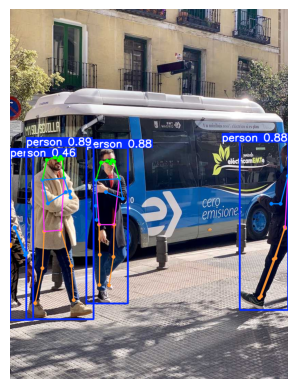

In [ ]:
for result in results:
    annotated_image = result.plot()
    plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

## Сегментация - Segmentation

https://docs.ultralytics.com/ru/tasks/segment/


Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 18.4ms
Speed: 2.2ms preprocess, 18.4ms inference, 40.9ms postprocess per image at shape (1, 3, 640, 480)


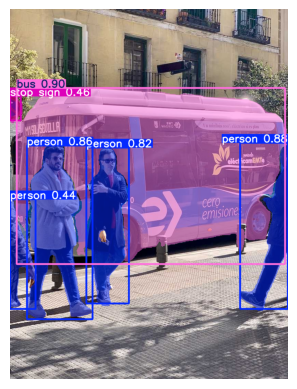

In [ ]:
model = YOLO('yolo11n-seg.pt')

image_path = 'https://ultralytics.com/images/bus.jpg'
results = model(image_path)

for result in results:
    annotated_image = result.plot()
    plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

## Классификация - classification

https://docs.ultralytics.com/ru/tasks/classify/

In [ ]:
model = YOLO('yolo11n-cls.pt')

image_path = 'https://ultralytics.com/images/bus.jpg'
results = model(image_path)


for result in results:
    probs = result.probs
    print(f"Предсказанный класс: {probs.top1} - {model.names[probs.top1]}")
    print(f"Вероятность: {probs.top1conf:.2f}")




Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /content/bus.jpg: 224x224 minibus 0.57, police_van 0.34, trolleybus 0.04, recreational_vehicle 0.01, streetcar 0.01, 4.1ms
Speed: 15.6ms preprocess, 4.1ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
Предсказанный класс: 654 - minibus
Вероятность: 0.57


## Ключевые точки (Оценка позы)

https://docs.ultralytics.com/ru/tasks/pose/


Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /content/bus.jpg: 640x480 4 persons, 23.8ms
Speed: 2.4ms preprocess, 23.8ms inference, 5.4ms postprocess per image at shape (1, 3, 640, 480)


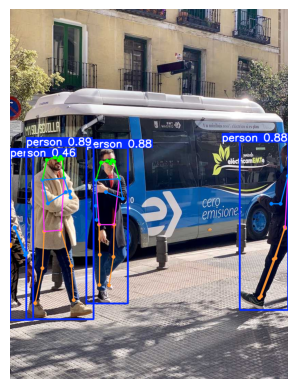

In [ ]:
model = YOLO('yolo11n-pose.pt')

image_path = 'https://ultralytics.com/images/bus.jpg'
results = model(image_path)

for result in results:
    annotated_image = result.plot()
    plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

# Object Detection. Тюнинг YOLO на собственном датасете. Оценка модели.

Обнаружение объектов — это основная задача YOLO, где модель предсказывает bounding boxes (прямоугольники) вокруг объектов и их классы. YOLO отлично подходит для работы в реальном времени благодаря своей скорости.

**Как дообучить YOLO для обнаружения объектов на своем датасете?**

Дообучение (fine-tuning) позволяет адаптировать предобученную модель к новым данным. Для дообучения нужен датасет в формате YOLO (файлы .txt с аннотациями и изображения). Если разметки нет можно использовать специальный инструмент, например LabelImg или MakeSense. Для запуска обучения надо также создать файл data.yaml с путями к тренировочным/валидационным данным и классами.

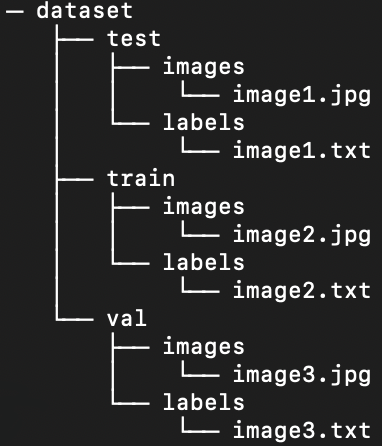

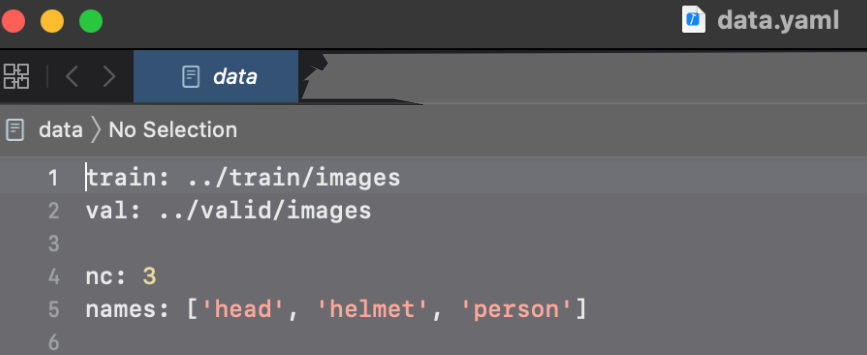

## Пример с загрузкой датасета

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="rf_wrTiH5oaZtYWiF0qNrI9a28Mw0d2")
project = rf.workspace("tarik-yilmaz-kanzileri").project("detection-f1-cars")
version = project.version(12)
dataset = version.download("yolov11")


RuntimeError: {
    "error": {
        "message": "This API key does not exist (or has been revoked).",
        "status": 401,
        "type": "OAuthException",
        "hint": "You may retrieve your API key via the Roboflow Dashboard. Go to Account > Roboflow Keys to retrieve yours.",
        "key": "rf_wrTiH5oaZtYWiF0qNrI9a28Mw0d2"
    }
}

In [ ]:
model = YOLO("yolo11n.pt")
results = model.train(data="/content/detection-f1-cars-12/data.yaml", epochs=10, imgsz=640)

Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/detection-f1-cars-12/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=T

RuntimeError: Dataset '/content/detection-f1-cars-12/data.yaml' error ❌ '/content/detection-f1-cars-12/data.yaml' does not exist